# Composing Functions

**This notebook is self-contained; it recaps what a function is before composing them.**

Recall that a **function** is a rule that turns an input into exactly one output, a machine you feed a number, and it hands one back. Real processes are often several such machines **chained together**: a drug dose sets a blood concentration, and that concentration produces an effect. Feeding the output of one function straight into another is called **composition**, and it lets us describe a multi-step process with a single combined function.

## Learning objectives

- Compute a composition $(f \circ g)(x) = f(g(x))$.
- Show that **order matters**: $f \circ g$ is usually not the same as $g \circ f$.
- Read a composition as a chain of steps.

## Background

**Composition** applies one function to the result of another:

$$(f \circ g)(x) = f(g(x)).$$

Read it from the **inside out**: first apply the inner function $g$ to $x$, then apply the outer function $f$ to that result. Because $g$ happens first and $f$ second, swapping their order usually changes the answer, so in general $f \circ g \ne g \circ f$.

## This notebook covers

1. Composing two functions.
2. Why order matters.
3. A chain of steps (an application).

**Prerequisites:** `U1-3_Functions-1_DomainRangeAndFamilies`

**Dataset:** none.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# --- plotting helper: draw x-y graphs like the usual coordinate plane ---
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. Composing two functions

Take two simple machines: $g(x) = x + 1$ (add one) and $f(x) = x^2$ (square). The composition $f(g(x))$ runs $g$ first and then $f$, it **adds one, then squares**. So $f(g(2))$ means: start with $2$, add one to get $3$, then square to get $9$.

g(2)    = 3
f(g(2)) = 9


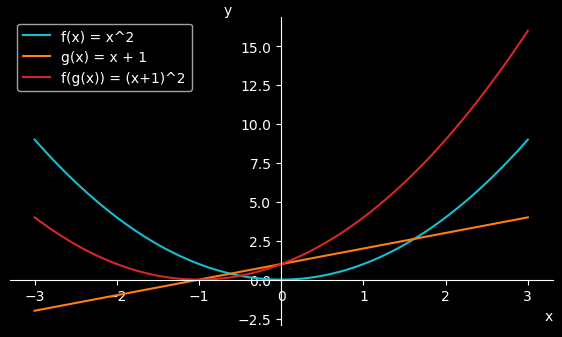

In [2]:
def g(x):
    return x + 1        # first: add 1

def f(x):
    return x ** 2       # then: square

x = np.linspace(-3, 3, 100)

# Compose by hand: first g, then f.
composition = f(g(x))

print("g(2)    =", g(2))       # 3
print("f(g(2)) =", f(g(2)))    # 9

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, f(x), label="f(x) = x^2", color="tab:cyan")
ax.plot(x, g(x), label="g(x) = x + 1", color="tab:orange")
ax.plot(x, composition, label="f(g(x)) = (x+1)^2", color="tab:red")
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.legend()
plt.show()

## 2. Why order matters

If we swap the order to $g(f(x))$, the machine now **squares first and then adds one**, a genuinely different rule. Starting from $2$: square to get $4$, then add one to get $5$. Computing both compositions at the same input shows they disagree.

In [3]:
x_value = 2

f_then = f(g(x_value))   # f(g(2)): add 1, then square -> (2+1)^2 = 9
g_then = g(f(x_value))   # g(f(2)): square, then add 1 -> 2^2 + 1 = 5

print("f(g(2)) =", f_then)
print("g(f(2)) =", g_then)
print("Same?", f_then == g_then)

f(g(2)) = 9
g(f(2)) = 5
Same? False


The two results differ (9 vs 5), so the order of composition changes the answer.

## 3. A chain of steps

Composition is the natural way to model a pipeline. Suppose a dose $d$ (in mg) produces a blood concentration $c(d) = 0.5\,d$, and that concentration produces an effect $e(c) = 10\sqrt{c}$. The overall "dose to effect" relationship is the composition $e(c(d))$, first compute the concentration, then feed it into the effect function.

In [4]:
def concentration(dose):
    return 0.5 * dose          # step 1: dose -> concentration

def effect(conc):
    return 10 * np.sqrt(conc)  # step 2: concentration -> effect

dose = 8.0

# Compose the two steps.
c = concentration(dose)
e = effect(c)

print("dose:", dose, "-> concentration:", c, "-> effect:", round(e, 2))
print("directly, effect(concentration(dose)) =", round(effect(concentration(dose)), 2))

dose: 8.0 -> concentration: 4.0 -> effect: 20.0
directly, effect(concentration(dose)) = 20.0


## 4. Summary

- **Composition** $(f \circ g)(x) = f(g(x))$ feeds one function's output into another: inner function first.
- **Order matters:** $f \circ g$ is usually different from $g \circ f$.
- Composition models step-by-step pipelines (dose → concentration → effect).

Next: undoing a function with its **inverse** (`U1-3_Functions-3_Inverse`).